In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from overview import FigureType, StatisticLine, feature_overview


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
data = pd.concat([comp, orig])

# load test part
test = pd.read_csv('data/test.csv', index_col='id').astype({'Sex': 'category'})

### Basics

__Original__

In [83]:
orig.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
User_ID,,,,,,,,
14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [84]:
orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 14733363 to 11751526
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Sex         15000 non-null  category
 1   Age         15000 non-null  int64   
 2   Height      15000 non-null  float64 
 3   Weight      15000 non-null  float64 
 4   Duration    15000 non-null  float64 
 5   Heart_Rate  15000 non-null  float64 
 6   Body_Temp   15000 non-null  float64 
 7   Calories    15000 non-null  float64 
dtypes: category(1), float64(6), int64(1)
memory usage: 952.3 KB


In [85]:
orig.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


__Competition__

In [86]:
comp.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
id,,,,,,,,
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [87]:
comp.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [88]:
comp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   Sex         750000 non-null  category
 1   Age         750000 non-null  int64   
 2   Height      750000 non-null  float64 
 3   Weight      750000 non-null  float64 
 4   Duration    750000 non-null  float64 
 5   Heart_Rate  750000 non-null  float64 
 6   Body_Temp   750000 non-null  float64 
 7   Calories    750000 non-null  float64 
dtypes: category(1), float64(6), int64(1)
memory usage: 46.5 MB


### Features overview

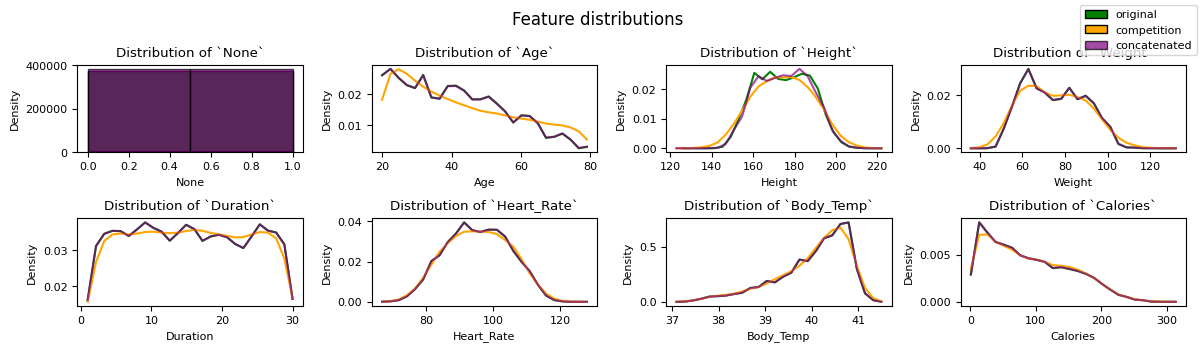

In [112]:
COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if data[feature].dtype == 'category':
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[data.index < 1e6, feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='green')
        feature_overview(ax[row][col], data.loc[data.index > 1e6, feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='orange')
        feature_overview(ax[row][col], data[feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='purple', alpha=0.7)
    else:
        feature_overview(ax[row][col], data.loc[data.index < 1e6, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[data.index > 1e6, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple', alpha=0.7)

fig.legend(['original', 'competition', 'concatenated'])
plt.show()

__distributions by Sex__

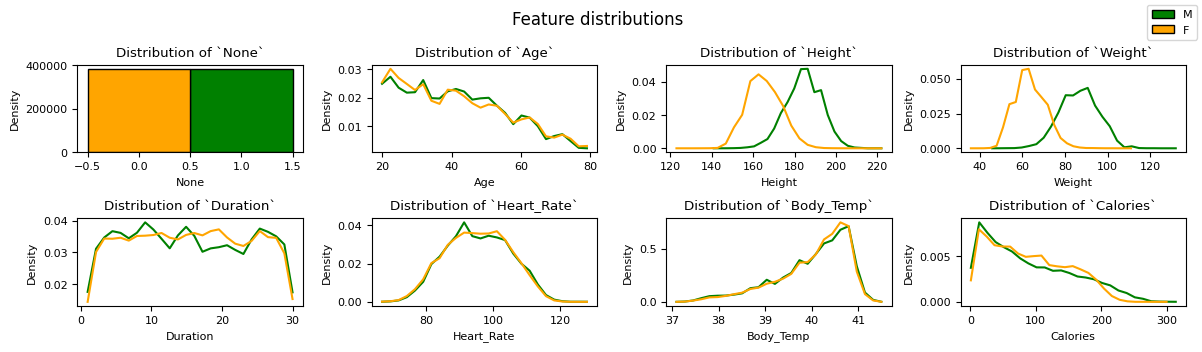

In [114]:
COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex == 'male'
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if data[feature].dtype == 'category':
        feature_overview(ax[row][col], data.loc[MALE, feature].cat.codes, FigureType.HIST, bins=1, edgecolor='black', color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature].cat.codes, FigureType.HIST, bins=1, edgecolor='black', color='orange')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')

fig.legend(['M', 'F'])
plt.show()

__test distributions__

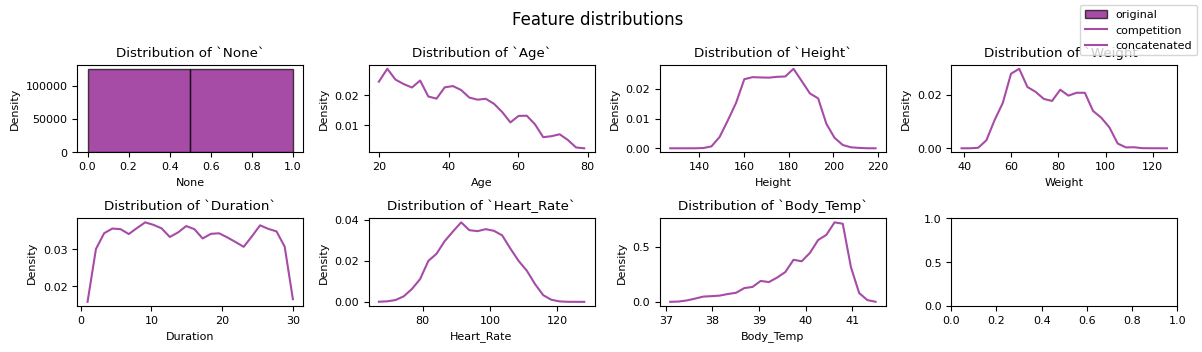

In [ ]:
COLUMNS = 4
ROWS = np.ceil(len(test.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(test.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if test[feature].dtype == 'category':
        bins = test[feature].unique().size
        # feature_overview(ax[row][col], test.loc[test.index < 1e6, feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='green')
        # feature_overview(ax[row][col], test.loc[test.index > 1e6, feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='orange')
        feature_overview(ax[row][col], test[feature].cat.codes, FigureType.HIST, bins=bins, edgecolor='black', color='purple', alpha=0.7)
    else:
        # feature_overview(ax[row][col], test.loc[test.index < 1e6, feature], FigureType.DENSITY, bins=25, color='green')
        # feature_overview(ax[row][col], test.loc[test.index > 1e6, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], test[feature], FigureType.DENSITY, bins=25, color='purple', alpha=0.7)

fig.legend(['original', 'competition', 'concatenated'])
plt.show()

In [ ]:
INCLUDE_TARGET = True
ORIGIN = df.columns.to_list()

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),

    # Body-mass index
    # Calc('Weight / (Height / 100) ** 2', to='BMI'),
    Calc('np.round(Weight / (Height / 100) ** 2, 1)', to='BMI'),  # for grouping

    # Calc('Body_Temp / Duration', to='BodyTempDuration_Ratio'),
    Calc('Weight / Heart_Rate', to='WeightHeartRate_Ratio'),
    Calc('Weight / Duration', to='WeightDuration_Ratio'),
    Calc('Heart_Rate / Duration', to='HeartRateDuration_Ratio'),
    Calc('Heart_Rate / Body_Temp', to='HeartRateBodyTemp_Ratio'),

    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='activity_index'),
    Calc('np.log((Heart_Rate * Body_Temp * Duration * Age) ** (Weight / Height))', to='one_more_index'),

    # bins
    # Bins('Age', to='ct_Age', bins=25),
    # Bins('Duration', to='ct_Duration', bins=25),
    Bins('Weight', to='ct_Weight', bins=50),
    Bins('Height', to='ct_Height', bins=50),

    # groups
    # WithSelected(r'(?!Sex|mean_|ct_)')(Group('Age', 'mean', prefix='mean_Age_', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!Sex|mean_|ct_)')(Group('Duration', 'mean', prefix='mean_Duration_', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!Sex|mean_|ct_)')(Group('Weight', 'mean', prefix='mean_Weight', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!mean_|ct_)')(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!mean_|ct_)')(Group(['Sex', 'Duration'], 'mean', prefix='mean_SexDuration_', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!Sex|mean_|ct_)')(Group(['Age', 'Duration'], 'mean', prefix='mean_AgeDuration_', include_target=INCLUDE_TARGET)),
    # WithSelected(r'(?!Sex|mean_|ct_)')(Group(['Weight', 'Duration'], 'mean', prefix='mean_WeightDuration_', include_target=INCLUDE_TARGET)),

    # EXPERIMENTAL
    # WithSelected(r'(?!mean_|ct_)')(Group(['Age', 'Weight', 'Sex', 'Duration'], 'mean', prefix='mean_AgeWeightSexDuration_', include_target=INCLUDE_TARGET)),
    WithSelected(r'(?!mean_|ct_Height)')(Group(['Age', 'Sex', 'ct_Weight', 'Duration'], 'mean', prefix='mean_AgeSexWeightDuration_', include_target=INCLUDE_TARGET)),
    WithSelected(r'(?!mean_|ct_Weight)')(Group(['Age', 'Sex', 'ct_Height', 'Duration'], 'mean', prefix='mean_AgeSexHeightDuration_', include_target=INCLUDE_TARGET)),
    WithSelected(r'(?!mean_|ct_)')(Group(['Age', 'Sex', 'BMI'], 'mean', prefix='mean_AgeSexBMI_', include_target=INCLUDE_TARGET)),


    # drop columns
    # Select(['Sex', 'Age', 'Height'], mode='drop'),
    # Select(r'mean_|Sex|activity_index', mode='keep'),

    # fill NaN
    Fill('mean'),

    # # standardize: keep Sex [0, 1]
    # WithSelected(r'(?!Sex)')(
    #     KeepDataframe(make_pipeline(
    #         # pre.QuantileTransformer(random_state=17),
    #         pre.PowerTransformer(standardize=True),
    #         # pre.PowerTransformer(standardize=False),
    #         # pre.MinMaxScaler(),
    #         # pre.StandardScaler(),
    #         # pre.RobustScaler(),
    #     )),
    # ),
    # standardize whole dataset
    KeepDataframe(make_pipeline(
        # pre.QuantileTransformer(random_state=17),
        pre.PowerTransformer(standardize=True),
        # pre.PowerTransformer(standardize=False),
        # pre.MinMaxScaler(),
        # pre.StandardScaler(),
        # pre.RobustScaler(),
    )),
)
y_pipe = pre.PowerTransformer()

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = y_pipe.fit_transform(df[TARGET].to_numpy().reshape(-1, 1))[:, 0]
# y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,WeightHeartRate_Ratio,WeightDuration_Ratio,...,mean_AgeSexBMI_Duration,mean_AgeSexBMI_Heart_Rate,mean_AgeSexBMI_Body_Temp,mean_AgeSexBMI_WeightHeartRate_Ratio,mean_AgeSexBMI_WeightDuration_Ratio,mean_AgeSexBMI_HeartRateDuration_Ratio,mean_AgeSexBMI_HeartRateBodyTemp_Ratio,mean_AgeSexBMI_activity_index,mean_AgeSexBMI_one_more_index,mean_AgeSexBMI_Calories
0,1.002026,-0.219612,1.108992,0.547669,1.211090,0.585749,1.638742,-0.906761,0.197729,-0.877680,...,1.719146,0.0,1.590701,-0.009631,-1.361019,-1.854508,1.211288,-1.910066,-0.008169,0.791791
1,-0.997979,1.363915,-0.906548,-1.102767,-0.845137,-1.109845,-0.672938,-1.171111,-0.463284,0.531630,...,0.464249,0.0,0.060539,-1.137574,-0.334091,0.356726,0.177168,-0.146378,-0.811933,0.789655
2,-0.997979,0.722080,-1.067658,-0.769093,-0.983984,-1.216566,-0.551621,0.215825,-0.103652,0.773512,...,0.166689,0.0,0.644389,-0.792452,-0.628576,-0.255279,-0.112670,-0.325087,-0.306601,0.199904
3,1.002026,-1.692237,1.332903,1.056994,1.110331,1.006406,0.938071,0.017825,0.456178,-0.625360,...,-0.558550,0.0,-0.457494,0.664032,0.709804,0.466626,-0.121547,0.502326,0.013329,-1.646581
4,-0.997979,-0.076815,-0.666616,-1.017667,1.110331,0.691028,0.730656,-1.501666,-1.229332,-1.400783,...,-0.257958,0.0,-0.444898,-1.107087,-0.485781,0.278137,-0.229985,0.413699,-1.251611,-0.204136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,-0.997979,-1.692237,1.407174,0.807240,-0.452275,-0.365346,0.350830,-0.840686,0.870348,0.584738,...,-0.577954,0.0,-0.611973,-0.883063,0.036973,0.799200,-0.771891,0.638532,-1.356341,-0.959509
764996,-0.997979,-0.958619,-0.746365,-0.688371,-1.127824,-1.109845,-1.180681,-0.312272,-0.086291,0.958762,...,-0.138606,0.0,-0.379748,-0.718453,0.132670,0.901433,-0.406092,0.282210,-0.851282,-0.515867
764997,-0.997979,0.254321,-1.229713,-1.276535,0.145903,-0.577617,-0.140713,-0.972840,-0.886928,-0.612512,...,0.774130,0.0,0.821549,-1.067076,-1.406116,-1.045618,0.379334,-0.959149,-0.833431,0.537406
764998,1.002026,1.941359,1.407174,1.472735,-1.779280,-1.216566,-1.781218,1.073332,1.876284,1.930013,...,2.785208,0.0,1.317665,1.031211,1.438349,0.890596,3.432146,-0.960547,1.812831,4.060925


__Correlations__

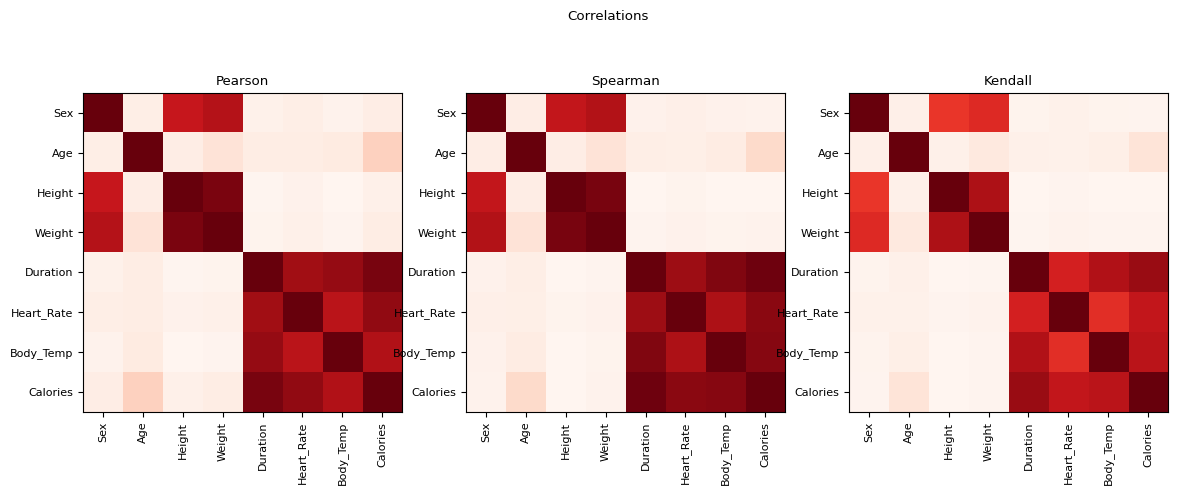

In [109]:
dt = data.copy()
dt.Sex = dt.Sex.cat.codes

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# drawing
fig, axes = plt.subplots(1, len(CORRELATIONS), figsize=(14, 5))
# fig.set_layout_engine('none')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    # ax[n].tick_params(axis='x', rotation=90)
    ax.imshow(dt.corr(method), cmap='Reds')
    ax.set_xticks(range(len(dt.columns)), labels=dt.columns, rotation=90)
    ax.set_yticks(range(len(dt.columns)), labels=dt.columns)
plt.show()

In [ ]:
#